## Z-test on Real Dataset — Student Performance (Kaggle)

**Dataset:** StudentsPerformance.csv
**Download from:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

**Question:**
Is the average math score of our sample significantly
different from the population mean of 66?

**H0:** Sample mean = 66
**H1:** Sample mean ≠ 66

## One sample Z-test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
df = pd.read_csv('/content/StudentsPerformance[1].csv')
print(df.head())
print(df.shape)
print(df.columns)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'w

In [6]:
math_score = df['math score']
population_mean = 66
sample_mean = np.mean(math_score)
sample_std = np.std(math_score)
sample_size = len(math_score)

print(f'Sample Mean: {sample_mean}')
print(f'Sample Standard Deviation: {sample_std}')
print(f'Sample Size: {sample_size}')

Sample Mean: 66.089
Sample Standard Deviation: 15.155496659628165
Sample Size: 1000


In [7]:
from statsmodels.stats.weightstats import ztest

z_stat , p_val = ztest(math_score, value = population_mean)

print(z_stat)
print(p_val)

if p_val < 0.05:
  print('reject H0')
  print('The average math score of our sample is significantly different from the population mean of 66.')
else:
  print('fail to reject H0')
  print('The average math score of our sample is not significantly different from the population mean of 66.')


0.18561051578765336
0.852750206464778
fail to reject H0
The average math score of our sample is not significantly different from the population mean of 66.


## Two Sample Z-Test on Real Data

**Question:**
Are math scores of Male and Female students significantly different?

**H0:** Male mean = Female mean
**H1:** Male mean ≠ Female mean

In [12]:
male_score = df[df['gender'] == 'male']['math score']
female_score = df[df['gender'] == 'female']['math score']
print(f'Male score mean : {np.mean(male_score)}')
print(f'Female score mean : {np.mean(female_score)}')


Male score mean : 68.72821576763485
Female score mean : 63.633204633204635


In [16]:
z_stat , p_val = ztest(male_score, female_score)

print(z_stat)
print(p_val)

if p_val < 0.05:
  print('reject H0')
  print('Math scores of Male and Female students are significantly different.')
else:
  print('fail to reject H0')
  print('Math scores of Male and Female students are not significantly different.')


5.383245869828983
7.31545037956675e-08
reject H0
Math scores of Male and Female students are significantly different.


## Visualization

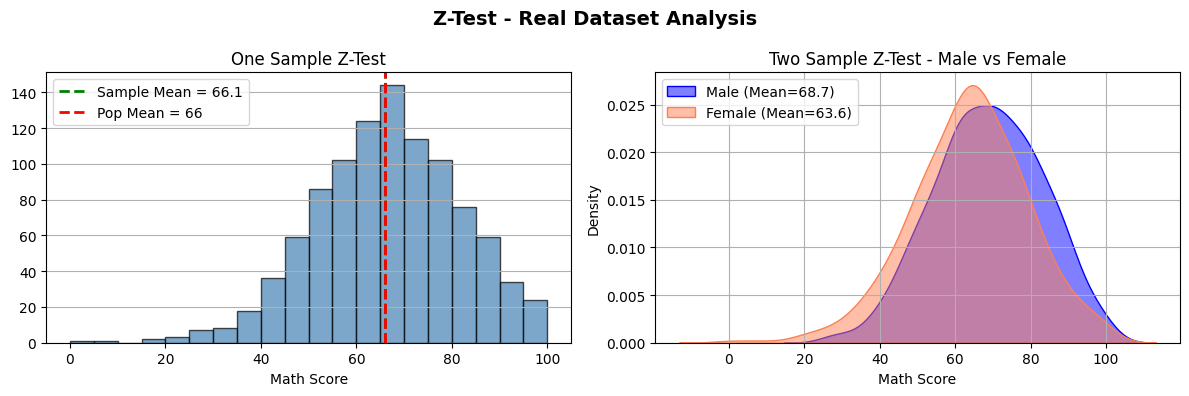

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One Sample
axes[0].hist(math_score, bins=20, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(sample_mean,     color="green", linestyle="--", linewidth=2, label=f"Sample Mean = {sample_mean:.1f}")
axes[0].axvline(population_mean, color="red",   linestyle="--", linewidth=2, label=f"Pop Mean = {population_mean}")
axes[0].set_title("One Sample Z-Test")
axes[0].set_xlabel("Math Score")
axes[0].legend()
axes[0].grid(axis="y")

# Two Sample
sns.kdeplot(male_score,   fill=True, color="blue",  alpha=0.5, label=f"Male (Mean={male_score.mean():.1f})",   ax=axes[1])
sns.kdeplot(female_score, fill=True, color="coral", alpha=0.5, label=f"Female (Mean={female_score.mean():.1f})", ax=axes[1])
axes[1].set_title("Two Sample Z-Test - Male vs Female")
axes[1].set_xlabel("Math Score")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Z-Test - Real Dataset Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook I covered:

- What is Z-Test and When to use it
- Hypothesis (H0 and H1)
- Z-Score Formula
- One Sample Z-Test (Self Made Dataset)
- Two Sample Z-Test (Self Made Dataset)
- One Sample Z-Test (Kaggle - Real Dataset)
- Two Sample Z-Test (Kaggle - Male vs Female)
- Visualizations